### Jeremy Marino

### DS4420

### Final Project 

### College Baseball Seasonal Pitching/Hitting Analysis - Time Series

## Time Series Model Goals

### Steps to implement
- Load and clean the data
- Choose batting and pitching metrics
- Standardize the stats if needed
- Encode teams, conferences, and seasons
- Fit Time Series model
- Understand relation between pitching and batting. Predict furture relationships

## Hypothesis

The reason I believe this project to be so interest is because of the relationships between the different divisions of play. I am of the opinion that the trends may differ by division because of disparity of talent between levels. Because of this, I believe the higher the division, the closer the teams and conferences will follow professional in terms of pitching and battling (i.e. higher strikeout rates and higher home run/SLG rates).

## Load/Clean Data

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import AutoReg

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [32]:
div1_df = pd.read_json(r'C:\Users\Jerem\Documents\NU SPRING 2026\DS4420\FINAL PROJECT\DS4420-BiggsMarino-Final-Project\Data\div1\2012.json').T
div1_df.shape

(292, 46)

In [125]:
div1_df.head(10)

,team,league,W,L,T,WPCT,G,BB (Batting),AB,H,...,SLG,SBPG,SO,BB (Pitching),K/BB,K/9,3B,3BPG,WHIP,BBPG (Pitching)
Utah Valley (GWC),Utah Valley,GWC,47,12,0,0.797,59,271,2031,711,...,0.523,0.92,347,169,2.05,6.3,30,0.51,1.47,3.08
Stony Brook (America East),Stony Brook,America East,52,15,0,0.776,67,243,2245,743,...,0.478,1.37,394,176,2.24,6.2,36,0.54,1.18,2.78
Purdue (Big Ten),Purdue,Big Ten,45,14,0,0.763,59,187,2107,665,...,0.431,1.03,364,128,2.84,6.2,17,0.29,1.21,2.18
UCLA (Pac-12),UCLA,Pac-12,48,16,0,0.75,64,228,2135,650,...,0.393,0.94,436,238,1.83,6.9,16,0.25,1.3,3.76
Florida St. (ACC),Florida St.,ACC,50,17,0,0.746,67,386,2230,627,...,0.414,0.94,498,228,2.18,7.5,10,0.15,1.33,3.43
Baylor (Big 12),Baylor,Big 12,49,17,0,0.742,66,296,2183,675,...,0.442,1.45,448,185,2.42,6.9,17,0.26,1.2,2.86
North Carolina (ACC),North Carolina,ACC,46,16,0,0.742,62,304,2127,587,...,0.384,1.15,530,205,2.59,8.5,25,0.4,1.25,3.27
Arizona (Pac-12),Arizona,Pac-12,48,17,0,0.738,65,234,2296,756,...,0.447,1.31,443,168,2.64,6.8,35,0.54,1.27,2.58
Army West Point (Patriot),Army West Point,Patriot,41,15,0,0.732,56,197,1748,502,...,0.362,1.95,346,148,2.34,6.6,7,0.13,1.2,2.81
UCF (CUSA),UCF,CUSA,45,17,0,0.726,62,277,2128,617,...,0.418,1.45,484,238,2.03,7.7,12,0.19,1.4,3.79


Mateo has pretty well structured data here for all 3 levels of college baseball, most of the wrangling will involve aggragting seasonal data into groups by conference, division, etc.

## Batting/Pitching Metrics

These are our initial metrics we will pass in as features for our model. They are not necessarily the best and our subject to change, however they provide a good baseline for our model.

Here is the documentation for features in this dataset: https://collegebaseballstatspackage.readthedocs.io/en/latest/season_stats.html 

### Batting Metrics

- BA (Batting Average)
- OBP (On-Base Percentage)
- SLG (Slugging Percentage)
- HRPG (Home-Run Percentage)
- RPG (Runs Per Game)

### Pitching Metrics

- ERA (Earned Run Average)
- WHIP (Walks and Hits Per Inning Pitched)
- K/9 (Strikeouts Per 9 Innings Pitched)
- K/BB (Strikeouts / Walk Ratio)

In [175]:
# returns dict with historic conference data
def get_historic_conference_data(div=1):
    conf_dict = {}
    # data is from 2012-2025
    for year in range(2012, 2026):
        path = f'C:/Users/Jerem/Documents/NU SPRING 2026/DS4420/FINAL PROJECT/DS4420-BiggsMarino-Final-Project/Data/div{div}/{year}.json'
        df = pd.read_json(path).T
        year_confs = [conf.replace(' ', '_') for conf in df['league'].unique()[:-1]] 
        for conf, conf_ in zip(df['league'].unique()[:-1], year_confs):
            conf_dict[f'{conf_}_{year}'] = {
                'BA': round(float(df[df['league'] == conf]['BA'].mean()), 3),
                'OBP': round(float(df[df['league'] == conf]['OBP'].mean()), 3),
                'SLG': round(float(df[df['league'] == conf]['SLG'].mean()), 3),
                'HRPG': round(float(df[df['league'] == conf]['HRPG'].mean()), 3),
                'RPG': round(float(df[df['league'] == conf]['RPG'].mean()), 3),
                'ERA': round(float(df[df['league'] == conf]['ERA'].mean()), 3),
                'WHIP': round(float(df[df['league'] == conf]['WHIP'].mean()), 3),
                'K/9': round(float(df[df['league'] == conf]['K/9'].mean()), 3),
                'K/BB': round(float(df[df['league'] == conf]['K/BB'].mean()), 3)
            }
    return conf_dict

In [191]:
DIV_1_CONFERENCES = [
    'America_East', 'Big_Ten', 'Pac-12', 'ACC', 'Big_12',
    'Patriot', 'CUSA', 'SEC', 'WCC', 'MAC', 'MEAC', 'Big_South',
    'Atlantic_10', 'SoCon', 'MVC', 'SWAC', 'Summit_League',
    'The_American', 'Southland', 'Mountain_West', 'ASUN', 'Big_West',
    'Ivy_League', 'Horizon', 'CAA', 'OVC', 'Sun_Belt', 'NEC', 'WAC',
    'MAAC'
]

# prints graph of conference's current trend, all_conf argument prints all conferences for the metric
# use conference notation above for conf_ argument 
def get_conf_trend(conf_dict, metric, conf_=None, all_conf=False):
    years = list(range(2012, 2026))
    plt.figure(figsize=(12, 6))

    if all_conf:
        # collect all conference values per year for division average
        year_values = {year: [] for year in years}

        for conf in sorted(DIV_1_CONFERENCES):
            values = []
            valid_years = []
            for year in years:
                key = f'{conf}_{year}'
                if key in conf_dict:
                    valid_years.append(year)
                    values.append(conf_dict[key][metric])
                    year_values[year].append(conf_dict[key][metric])
            plt.plot(valid_years, values, marker='o', alpha=0.4, label=conf)

        # division-wide average line
        avg_years = [y for y in years if year_values[y]]
        avg_values = [np.mean(year_values[y]) for y in avg_years]
        plt.plot(avg_years, avg_values, color='black', linewidth=2.5,
                 linestyle='--', marker='s', label='Division Avg')

        plt.title(f'{metric} Average by Conference since 2012')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
        
        years_return = avg_years
        values_return = avg_values
    else:
        values = []
        valid_years = []
        for year in years:
            key = f'{conf_}_{year}'
            if key in conf_dict:
                valid_years.append(year)
                values.append(conf_dict[key][metric])
        plt.plot(valid_years, values, marker='o', alpha=0.6)
        plt.title(f'{metric} Average in {conf_} since 2012')

        years_return = valid_years
        values_return = values
        
    plt.xlabel('Year')
    plt.ylabel(f'{metric} Average')
    plt.xticks(years, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return years_return, values_return

In [222]:
# print the acf and pacf graphs for a metric
# title name can be a conference or a division average
def get_acf_pacf(metric, title_name, values):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].grid(True, alpha=0.3)
    plot_acf(values, title=f'{title_name} {metric} ACF Plot')

    ax[1].grid(True, alpha=0.3)
    plot_pacf(values, title=f'{title_name} {metric} PACF Plot')

    plt.tight_layout()
    plt.show()

In [232]:
def get_acf_pacf(metric, title_name, metric_df):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    plot_acf(metric_df['avg'], ax=ax[0], title=f'{title_name} {metric} ACF Plot')
    ax[0].grid(True, alpha=0.3)

    plot_pacf(metric_df['avg'], ax=ax[1], title=f'{title_name} {metric} PACF Plot')
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [179]:
conf_dict = get_historic_conference_data(div=1)

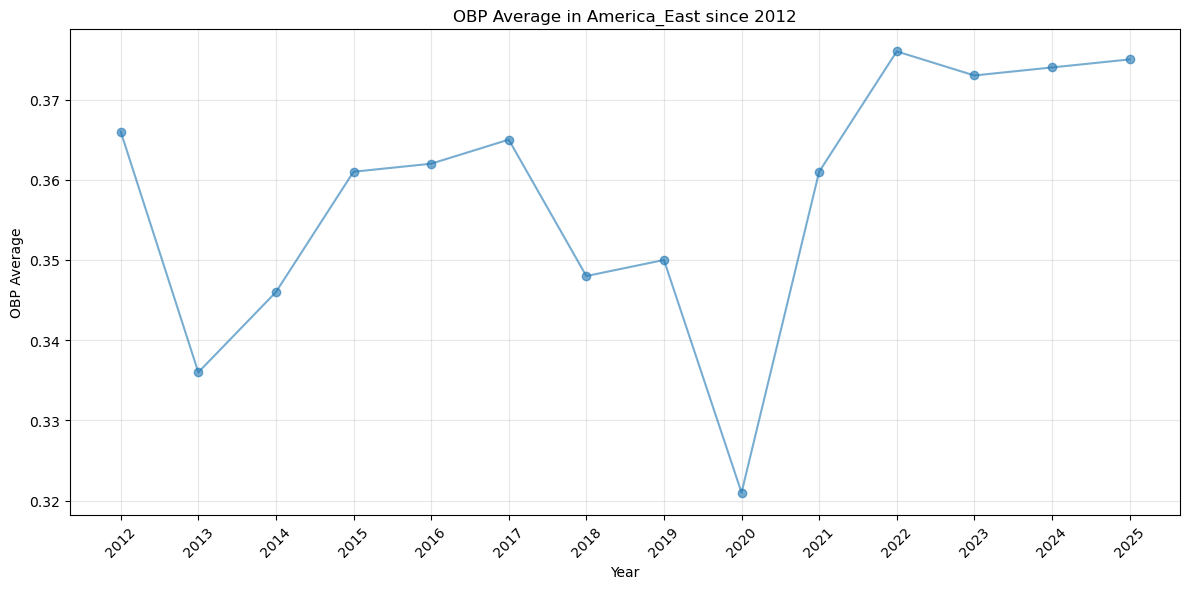

In [180]:
get_conf_trend(conf_dict, conf_='America_East', metric='OBP')

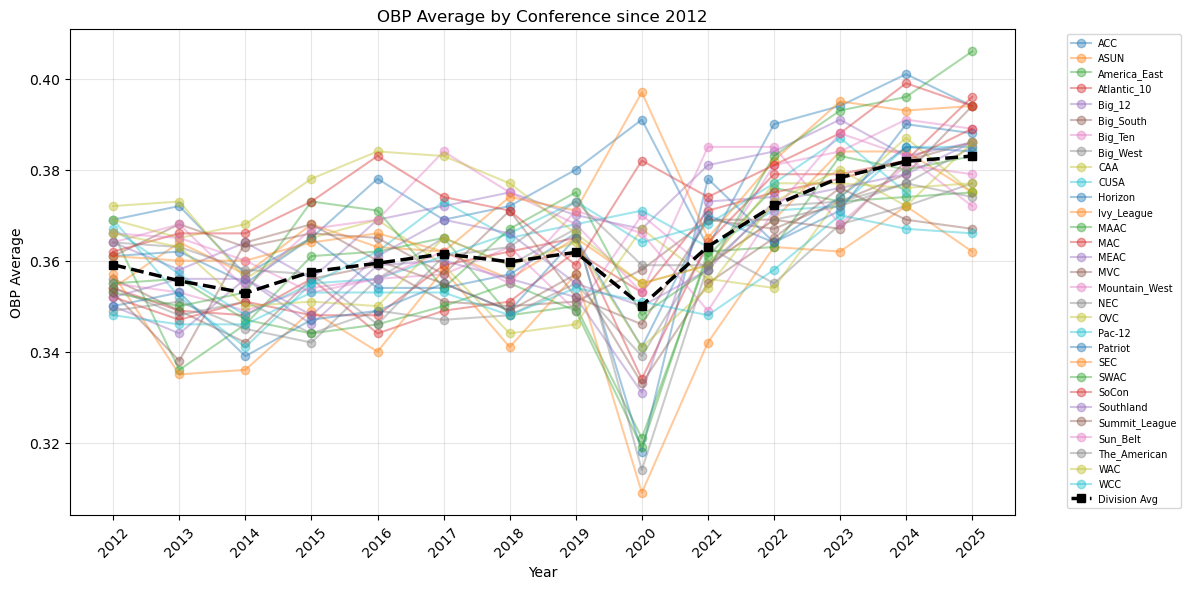

In [236]:
years, avg = get_conf_trend(conf_dict, metric='OBP', all_conf=True)
OBP_avg_df = pd.DataFrame({
    'year': years,
    'avg': avg,
})

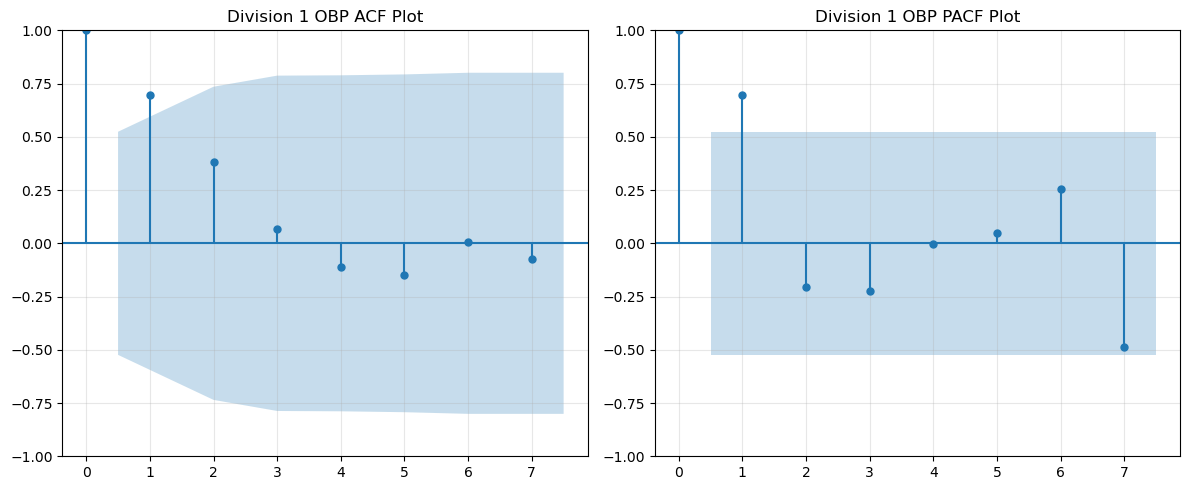

In [238]:
#years, avg
get_acf_pacf(metric='OBP', title_name='Division 1', metric_df=OBP_avg_df)